# 📚**Preparation**

In [ ]:
#@title Google Drive
from google.colab import drive, files
drive.mount('/content/drive', force_remount=True)
print("Google Drive ready!")

Mounted at /content/drive
Google Drive ready!


In [ ]:
#@title Albumentations

!pip install albumentations==1.3.1 opencv-python-headless -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 7.7 MB/s eta 0:00:00


In [ ]:
#@title Import Dependencies
# Standard library
import os
import math
import json
import re
import types

# Numerical & image processing
import numpy as np
import random
import cv2
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from scipy.special import erf
from PIL import Image

# Augmentation
import albumentations as A

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Data structures
from dataclasses import dataclass, fields

# **📊Configurations**

For tuning parameters.
Open to access.

In [ ]:
#@title Test Spot Config
#@markdown For testing single spots (so just ignore).

#@markdown Wont run unless you define the configs and the workflow.
do_this = False #@param {"type":"boolean"}
if do_this == True:
  try:
    show_image(create_primary_spot(CanvasConfig,show_upstream=True))
  except NameError:
    pass
  except AttributeError:
    pass

In [ ]:
#@title Canvas Configurations

@dataclass
class CanvasConfig:
#@markdown ---
    #@markdown **Dimensions**
    resolution_scale:         int   = 1
    base_height:              int   = 640    #@param {type:"integer"}
    aspect_ratio:             tuple = (1, 1) #@param {type:"raw"}
    base_width:               int   = base_height * aspect_ratio[0] // aspect_ratio[1]
#@markdown ---
    #@markdown **Spot Properties**

    #@markdown _Note: M is spot size_
    M:                        int   = 10      #@param {type:"integer"}
    point_resolution:         int   = 41      #@param {type:"integer"}
    max_int:                  float = 1    #@param {type:"slider", min:0, max:1, step:0.05}
    min_int:                  float = 0.65     #@param {type:"slider", min:0, max:1, step:0.05}
    top_length:               float = 112   #@param {type:"slider", min:0, max:112, step:1}
    bottom_length:            float = 17    #@param {type:"slider", min:0, max:112, step:1}
    left_length:              float = 25   #@param {type:"slider", min:0, max:112, step:1}
    right_length:             float = 25      #@param {type:"slider", min:0, max:112, step:1}
    length_deviation:         float = 0.35     #@param {type:"slider", min:0, max:1, step:0.05}
    target_percentile:        int = 20        #@param {type:"slider", min:0, max:100, step:1}
#@markdown ---
    #@markdown **Spot Size**
    size_mean:                float = 2.9   #@param {type:"number"}
    size_sd:                  float = 0.8  #@param {type:"number"}
    size_min:                 float = 1.2   #@param {type:"number"}
    size_max:                 float = 6   #@param {type:"number"}
#@markdown ---
    #@markdown **Clustering**
    clustering_prob:          float = 0.9     #@param {type:"slider", min:0, max:1, step:0.01}
    cluster_count_min:        int   = 2       #@param {type:"integer"}
    cluster_count_max:        int   = 7       #@param {type:"integer"}
    cluster_std_min:          float = 0.15    #@param {type:"number"}
    cluster_std_max:          float = 2    #@param {type:"number"}
    clustered_spot_ratio:     float = 0.8     #@param {type:"slider", min:0, max:1, step:0.01}
    cluster_size_falloff:     float = 2.0     #@param {type:"number"}
    cluster_size_deviation:   float = 0.1     #@param {type:"number"}
#@markdown ---
    #@markdown **Cluster Row Structure**

    #@markdown Note: Clusters are divided into rows.
    cluster_row_min:          int   = 2     #@param {type:"number"}
    cluster_row_max:          int   = 5     #@param {type:"number"}
    cluster_row_spacing_min:  float = 0.5   #@param {type:"number"}
    cluster_row_spacing_max:  float = 3   #@param {type:"number"}
    cluster_row_angle_min:    float = -5.0  #@param {type:"number"}
    cluster_row_angle_max:    float = 5.0   #@param {type:"number"}
    cluster_spot_spacing_min: float = 0.74   #@param {type:"slider", min:0, max:2, step:0.01}
    cluster_spot_spacing_max: float = 2.4   #@param {type:"slider", min:1, max:3, step:0.05}
    cluster_spot_deviation:   float = 1.1   #@param {type:"number"}
    cluster_split_prob:       float = 0.1   #@param {type:"number"}
    cluster_split_gap_min:    float = 0.6   #@param {type:"slider", min:0, max:1, step:0.05}
    cluster_split_gap_max:    float = 3.05   #@param {type:"slider", min:0, max:3.5, step:0.05}
#@markdown ---
    #@markdown **Primary Spot Count**
    spot_count_mean:          float = 120    #@param {type:"number"}
    spot_count_std:           float = 30    #@param {type:"number"}
    spot_count_min:           int   = 10      #@param {type:"integer"}
    spot_count_max:           int   = 230     #@param {type:"integer"}
#@markdown ---
    #@markdown **Secondary Spots**
    secondary_ratio_mean: float = 0         #@param {type:"number"}
    secondary_ratio_std:  float = 1         #@param {type:"number"}
    secondary_ratio_min:  float = 0         #@param {type:"number"}
    secondary_ratio_max:  float = 0         #@param {type:"number"}
    secondary_size_min:       float = 0.07     #@param {type:"slider", min:0, max:1, step:0.01}
    secondary_size_max:       float = 0.42     #@param {type:"slider", min:0, max:1, step:0.01}
    secondary_int_min:        float = 0.008   #@param {type:"slider", min:0, max:0.05, step:0.001}
    secondary_int_max:        float = 0.27     #@param {type:"slider", min:0, max:0.5, step:0.01}
#@markdown ---
    #@markdown **Bounding Box**
    bbox_intensity_threshold: float = 0.51    #@param {type:"slider", min:0, max:0.8, step:0.01}
    bbox_padding_px:          int   = 4       #@param {type:"slider", min:1, max:15, step:1}
#@markdown ---
#@markdown **Border Control**
    cluster_border_margin:    int   = 5    #@param {type:"integer"}
    spot_border_threshold:    float = 1.0   #@param {type:"number"}
#@markdown ---
    #@markdown **Background Distortion**
    const_bg_min:             float = 0.09     #@param {type:"slider", min:0, max:1, step:0.01}
    vary_bg_noise_size:       int   = 64      #@param {type:"slider", min:0, max:64, step:0.01}
    vary_bg_blur_sigma:       float = 100      #@param {type:"slider", min:0, max:100, step:5}
    vary_bg_intensity_min:    float = 0     #@param {type:"slider", min:0, max:1, step:0.01}
    vary_bg_intensity_max:    float = 0.28    #@param {type:"slider", min:0, max:1, step:0.01}
#@markdown ---
    #@markdown **Gaussian noise**
    gaussian_noise_var_min:   float = 0.00004  #@param {type:"slider", min:0, max:0.0002, step:0.00001}
    gaussian_noise_var_max:   float = 0.00041    #@param {type:"slider", min:0, max:0.002, step:0.00001}
    gaussian_noise_p:         float = 0.99     #@param {type:"slider", min:0, max:1, step:0.01}
#@markdown ---
#@markdown **Spot diffusion**
    diffuse_spots:                  bool  = True    #@param {type:"boolean"}
    diffuse_sigma:                  float = 1.8    #@param {type:"slider", min:0, max:3, step:0.1}

#@markdown ---
#@markdown **Streak Stuff**

    streak_crop_threshold:          float = 0.01

    streak_h_perp_draw_factor:      float = 1
    streak_h_perp_draw_extra:       int   = 3
    streak_v_perp_draw_factor:      float = 1.2
    streak_v_perp_draw_extra:       int   = 3
    streak_h_length_min:    float = 130.0    # px
    streak_h_length_max:    float = 500.0
    streak_v_length_min:    float = 200.0
    streak_v_length_max:    float = 700.0

    falloff_funcs:                  tuple = (
        "gaussian", "diffusion", "spline", "fl_bell", "sigmoid", "cosine"
    )

    streak_length_falloff_func:     str   = "spline"   # None = random per canvas

    streak_h_perp_falloff_func:     str   = "cosine"   # None = random per canvas
    streak_h_intensity_pct_mean:    float = 0.08
    streak_h_intensity_pct_sd:      float = 0.05
    streak_h_intensity_pct_min:     float = 0.01
    streak_h_intensity_pct_max:     float = 0.5

    streak_v_perp_falloff_func:     str   = "cosine"   # None = random per canvas
    streak_v_intensity_pct_mean:    float = 0.12
    streak_v_intensity_pct_sd:      float = 0.05
    streak_v_intensity_pct_min:     float = 0.03
    streak_v_intensity_pct_max:     float = 0.7

    streak_h_angle_min:   float = -2.0
    streak_h_angle_max:   float = 2.0
    streak_v_angle_min:   float = -2.0
    streak_v_angle_max:   float = 2.0

    gaussian_sigma_min:             float = 20.0
    gaussian_sigma_max:             float = 60.0
    gaussian_d_min:                 float = 0.0
    gaussian_d_max:                 float = 15.0

    diffusion_a_min:                float = 1.0
    diffusion_a_max:                float = 5.0
    diffusion_D_min:                float = 100.0
    diffusion_D_max:                float = 400.0

    spline_a_min:                   float = 5.0
    spline_a_max:                   float = 30.0
    spline_b_min:                   float = 20.0
    spline_b_max:                   float = 70.0

    fl_bell_a_min:                  float = 20.0
    fl_bell_a_max:                  float = 60.0
    fl_bell_b_min:                  float = 1.0
    fl_bell_b_max:                  float = 4.0

    sigmoid_a_min:                  float = 0.05
    sigmoid_a_max:                  float = 0.2
    sigmoid_d_min:                  float = 30.0
    sigmoid_d_max:                  float = 80.0

    cosine_a_min:                   float = 30.0
    cosine_a_max:                   float = 80.0
    cosine_d_min:                   float = 0.0
    cosine_d_max:                   float = 20.0

    smear_blur_sigma:         float = 70.0
    smear_intensity_fraction: float = 1
    smear_intensity_max:      float = 0.85

#@markdown ---
    @property
    def canvas_w(self):
        return self.base_width * self.resolution_scale

    @property
    def canvas_h(self):
        return self.base_height * self.resolution_scale

    @property
    def spot_base_size(self):
        return self.M * 2 * self.resolution_scale

In [ ]:
#@title Spot Augmentation Configurations
@dataclass
class AugmentationConfig:
#@markdown ---
    #@markdown **ShiftScaleRotate**
    ssr_shift_limit:   float = 0      #@param {type:"slider", min:0, max:10, step:0.1}
    ssr_scale_limit:   float = 0.20   #@param {type:"slider", min:0, max:1, step:0.1}
    ssr_rotate_limit:  int   = 0      #@param {type:"slider", min:0, max:360, step:1}
    ssr_p:             float = 0.62   #@param {type:"slider", min:0, max:1, step:0.01}
    #@markdown _Note: Keep shift_limit and rotate_limit to 0_

#@markdown ---
    #@markdown **ElasticTransform**

    #@markdown _alpha: how far pixels are displaced_
    et_alpha:         float = 8.0     #@param {type:"slider", min:0, max:10, step:1}

    #@markdown _sigma: how smooth the displacement field is_
    et_sigma:         float = 3.0     #@param {type:"slider", min:0, max:10, step:1}
    et_p:             float = 0.13    #@param {type:"slider", min:0, max:1, step:0.01}
#@markdown ---
    #@markdown **OpticalDistortion**
    od_distort_limit:  float = 0.50   #@param {type:"slider", min:0, max:1, step:0.1}
    od_p:              float = 0.13   #@param {type:"slider", min:0, max:1, step:0.01}
#@markdown ---
    # General
    interpolation:     int   = cv2.INTER_CUBIC
    border_mode:       int   = cv2.BORDER_CONSTANT
    border_value:      float = 0.0

In [ ]:
#@title Config Import/Export
#@markdown Import currently only works for CanvasConfig.

def export_config(cfg, filename="canvas_config.txt"):
    from dataclasses import fields
    lines = ["# CanvasConfig – do not remove the  # type:  tags\n"]
    for f in fields(cfg):
        tname = f.type if isinstance(f.type, str) else f.type.__name__
        lines.append(f"{f.name} = {getattr(cfg, f.name)!r}  # type: {tname}\n")
    open(filename, "w").writelines(lines)
    print(f"Saved → {filename}  ({len(lines)-1} fields)")

def parse_config_to_dict(path: str) -> dict:
    TYPE_MAP = {
        "int": int,
        "float": float,
        "bool": lambda v: v.strip().lower() == "true",
        "tuple": lambda v: eval(v.strip()),
        "str": str,
    }
    pattern = re.compile(r"^\s*(\w+)\s*=\s*(.+?)\s*#\s*type:\s*(\w+)\s*$")
    parsed = {}
    with open(path) as f:
        for line in f:
            m = pattern.match(line)
            if not m:
                continue
            key, raw_value, type_name = m.groups()
            parsed[key] = TYPE_MAP.get(type_name, str)(raw_value)
    return parsed

def dict_to_class(d: dict):
    class CanvasConfig:
        @property
        def canvas_w(self):
            return self.base_width * self.resolution_scale
        @property
        def canvas_h(self):
            return self.base_height * self.resolution_scale
        @property
        def spot_base_size(self):
            return self.M * 2 * self.resolution_scale
    for k, v in d.items():
        setattr(CanvasConfig, k, v)
    return CanvasConfig

# ✏️**2DGE Sample Generation Pipeline**

The whole workflow, divided into:
1. Initialization
2. Primary Spot Generation
3. Bounding Box Generation
4. Secondary Spot Generation
5. Streak Generation
6. Smear Generation
7. Canvas Distortion
8. Canvas Composition
9. Pipeline Execution





## **1. Initialize**

In [ ]:
#@title Init Sample
def init_sample(cfg: CanvasConfig) -> dict:
    return {
        "cfg":                cfg,
        "primary":            [],
        "bboxes":             [],
        "secondary":          [],
        "primary_streaked":   [],
        "secondary_streaked": [],
        "canvas_distortion":  [],
        "gaussian_noise":     [],
    }

## **2. Create Primary Spots**

### Generation
Workflow based on paper.

In [ ]:
M = 28 #pixels

#### Falloff Generation

In [ ]:
# @title Set Parameter Ranges
# @markdown Default Ranges
# @markdown | Function | Parameter #1 | Min | Max | Parameter #2 | Min | Max |
# @markdown | :--- | :---: | :---: | :---: | :---: | :---: | :---: |
# @markdown | 1. Gaussian | 𝜎 | 2 | 15 | d | 0 | 5 |
# @markdown | 2. Diffusion | a | 3.5 | 8 | D | 0.2 | 10 |
# @markdown | 3. Spline | a | 0 | 5 | b | 5 | 35 |
# @markdown | 4. FL Bell-shaped | a | 2 | 20 | b | 1.2 | 8 |
# @markdown | 5. Sigmoid | a | 0.5 | 1 | d | 1 | 20 |
# @markdown | 6. Cosine | a | 2 | 20 | d | 0 | 10 |

# @markdown Set Ranges (":" as divider)

rng = np.random.default_rng()

gaussian_1 = "2:15" #@param {type:"string"}
gaussian_2 = "0:5" #@param {type:"string"}
diffusion_1 = "3.5:8" #@param {type:"string"}
diffusion_2 = "0.2:10" #@param {type:"string"}
spline_1 = "0:5" #@param {type:"string"}
spline_2 = "5:35" #@param {type:"string"}
fl_bell_1 = "2:20" #@param {type:"string"}
fl_bell_2 = "1.2:8" #@param {type:"string"}
sigmoid_1 = "0.5:1" #@param {type:"string"}
sigmoid_2 = "1:20" #@param {type:"string"}
cosine_1 = "2:20" #@param {type:"string"}
cosine_2 = "0:10" #@param {type:"string"}

def get_rand(range_string):
  low, high = map(float, range_string.split(":"))
  return rng.uniform(low, high)

# Apply like this: get_rand(gaussian_1)

In [ ]:
#@title Define Formulas

# These functions return single y from x (plus parameters) input

# Gaussian
def gaussian(x, sigma, d):
  # gaussian.gaussian_part = np.exp(-((x - d)**2) / (2 * sigma**2))
  # return np.where(x <= d, 1.0, gaussian.gaussian_part)
  if x <= d:
    return 1.0
  else:
    return np.exp((-(x-d)**2)/(2*(sigma**2)))

# Simplified Diffusion
from scipy.special import erf
def diffusion(x, a, D):
    diffusion.r = np.where(x == 0, 1e-10, np.abs(x)/np.sqrt(D))
    return (erf((a+diffusion.r)/2)+erf((a-diffusion.r)/2))/2 + (1/(diffusion.r*np.sqrt(np.pi)))*(np.exp(-((a+diffusion.r)/2)**2)-np.exp(-((a-diffusion.r)/2)**2))

# Spline
def spline(x, a, b):
  # a is the distance from the center to the beginning of the curve transition area
  # b is the distance from the a to the end of the curve transition area.
  mid = a + (b / 2)
  end = a + b
  if x < a:
    return 1.0
  elif a <= x < mid:
    return 1 - 2 * ((x - a) / b)**2
  elif mid <= x < end:
    return 2 * ((x - a - b) / b)**2
  else:
    return 0.0
  # if x < a:
  #   return 1.0
  # elif a <= x < (a + b)/2:
  #   return 1 - 2 * ((x - a) / b)**2
  # elif (a + b)/2 <= x < a+b:
  #   return 2 * ((x - a - b) / b)**2
  # else:
  #   return 0.0

# Fuzzy Logic
def fl_bell(x, a, b):
  return 1 / (1 + np.abs(x / a)**(2 * b))

# Sigmoid
def sigmoid(x, a, d):
  # raw_y = 1 / (1 + np.exp(a * (x - d)))
  # peak = 1 / (1 + np.exp(a * (0 - d)))
  # return raw_y / peak
  return 1 / (1 + np.exp(a * (x - d)))

# Raised Cosine
def cosine(x, a, d):
  if x < d:
    return 1.0
  elif d <= x < d + a:
    return 0.5 * (1 + np.cos(np.pi * (x - d) / a))
  else:
    return 0.0


# The goal is to return a nested list with the following format:
# [[x1,x2,x3,...], [y1,y2,y3,...]]
# so basically get a whole graph.

def create_graph(function, min_x, max_x, param_1, param_2, normalization=True, debug=False, max_intensity=0.9):
  # print(f"Function: {function.__name__}")

  # Get x list
  create_graph.x = np.linspace(min_x, max_x, 1000)
  # print(create_graph.x)

  # Get y list
  create_graph.y = []
  for x in create_graph.x:
    create_graph.y.append(function(x, param_1, param_2))
    # print(function(x, param_1, param_2))
  # print(create_graph.y)

  if normalization == True:
    create_graph.final_x = []
    create_graph.final_y = []
    create_graph.final_x = create_graph.x
    # for i in create_graph.x:
    #   create_graph.final_x.append((i-min(create_graph.x))/(max(create_graph.x)-min(create_graph.x)))
    for i in create_graph.y:
      create_graph.final_y.append((i-min(create_graph.y))*max_intensity/(max(create_graph.y)-min(create_graph.y)))
    # create_graph.final_y[0] = 1.0
    # create_graph.final_y[-1] = 0.0
  else:
    create_graph.final_x = create_graph.x
    create_graph.final_y = create_graph.y

  # Debugging
  if debug == True:
    print(f"Function: {function.__name__}")
    print(f"Min x: {min_x}")
    print(f"Max x: {max_x}")
    print(f"Param 1: {param_1}")
    print(f"Param 2: {param_2}")
    print(f"X: {create_graph.final_x[:5]}, ..., {create_graph.final_x[-5:]}")
    print(f"Y: {create_graph.final_y[:5]}, ..., {create_graph.final_y[-5:]}")

  return create_graph.final_x, create_graph.final_y


# Apply like this:
# create_graph(gaussian, 0, M, get_rand(gaussian_1), get_rand(gaussian_2))

#### Falloff Resampling

In [ ]:
def get_common_intensities(n_points=100, max_intensity=1):
  theta = np.linspace(0, np.pi, n_points)
  y_shared = 0.5 * (1- np.cos(theta))
  y_shared = y_shared * max_intensity
  return np.sort(y_shared)[::-1]

def resample_to_intensities(x_raw, y_raw, y_shared):
  y_inc = y_raw[::-1]
  x_inc = x_raw[::-1]
  y_shared_inc = y_shared[::-1]
  x_resampled_inc = np.interp(y_shared_inc, y_inc, x_inc)
  return x_resampled_inc[::-1]

In [ ]:
def set_arm_lengths(cfg:CanvasConfig):
  # spot config for whole canvas
  # max distance for right,left,bottom,top
  return (
      np.random.normal(loc=cfg.right_length, scale=cfg.length_deviation*(cfg.right_length**(1/2))),
      np.random.normal(loc=cfg.left_length, scale=cfg.length_deviation*(cfg.left_length**(1/2))),
      np.random.normal(loc=cfg.top_length, scale=cfg.length_deviation*(cfg.top_length**(1/2))),
      np.random.normal(loc=cfg.bottom_length, scale=cfg.length_deviation*(cfg.bottom_length**(1/3))),
      )

In [ ]:
def get_points_4_templates(cfg:CanvasConfig,show_upstream=False):
  arm_lengths = set_arm_lengths(cfg)
  max_intensity = random.uniform(CanvasConfig.min_int,CanvasConfig.max_int)
  common_y = get_common_intensities(n_points=CanvasConfig.point_resolution,max_intensity=max_intensity)
  x_profiles = []
  if show_upstream == True:
    plt.figure(figsize=(10, 6))
  for i in range(4):
    max_distance = arm_lengths[i]
    function_pick =  random.choice(["gaussian", "diffusion", "spline", "fl_bell", "sigmoid", "cosine"])
    x_raw, y_raw = eval(f"create_graph({function_pick}, 0, M, get_rand({function_pick}_1), get_rand({function_pick}_2), normalization=True, max_intensity={max_intensity})")
    x_resampled = resample_to_intensities(x_raw, y_raw, common_y)
    #delete last item in x_resampled, normalize target point to max distance + deviation
    x_resampled1 = x_resampled[:-1]
    x_resampled2 = []
    max_distance1 = np.random.normal(loc=max_distance, scale=0.3)
    for j in x_resampled1:
      x_resampled2.append(j*max_distance1/np.percentile(x_resampled1, CanvasConfig.target_percentile, method='nearest'))
    x_profiles.append(x_resampled2)
    if show_upstream == True:
      plt.plot(x_raw, y_raw, color=['red', 'blue', 'green', 'orange'][i],label=['Top', 'Bottom', 'Left', 'Right'][i])

  #delete last item in common_y, normalize to lowest intensity of 0
  common_y1 = common_y[:-1]
  common_y2 = []
  for i in common_y1:
    common_y2.append(i-min(common_y1))
  if show_upstream == True:
    plt.show()
  return x_profiles, common_y2

In [ ]:
#@title Show graphs
def show_resampled_graphs(x_profiles, common_y):
  plt.figure(figsize=(10, 6))
  colors = ['red', 'blue', 'green', 'orange']
  labels = ['Top', 'Bottom', 'Left', 'Right']

  for i in range(4):
      plt.plot(x_profiles[i], common_y, 'o-', color=colors[i], markersize=4, label=labels[i], alpha=0.6)

  plt.legend()
  plt.grid(True, which='both', linestyle='--', alpha=0.5)
  plt.show()
# show_resampled_graphs(*get_points_4_templates(CanvasConfig,show_upstream=True))

#### 3D Falloff Arrangement

In [ ]:
def twod_arrange(cfg:CanvasConfig,show_upstream=False):
  # x_profiles = [x_top, x_bottom, x_left, x_right]
  if show_upstream == False:
    x_profiles, common_y = get_points_4_templates(cfg)
  else:
    x_profiles, common_y = get_points_4_templates(cfg,show_upstream=True)

  top_coords = [[],[],[]]
  bottom_coords = [[],[],[]]
  left_coords = [[],[],[]]
  right_coords = [[],[],[]]

  def set_xyz(which,x,y,z):
    which[0].append(x)
    which[1].append(y)
    which[2].append(z)

  for i in range(len(common_y)):
    intensity = common_y[i]

    top_pt  = (0, x_profiles[0][i])
    set_xyz(top_coords,*top_pt,intensity)

    bottom_pt = (0, -x_profiles[1][i])
    set_xyz(bottom_coords,*bottom_pt,intensity)

    left_pt  = (-x_profiles[2][i], 0)
    set_xyz(left_coords,*left_pt,intensity)

    right_pt = (x_profiles[3][i], 0)
    set_xyz(right_coords,*right_pt,intensity)

  if show_upstream == True:
    show_resampled_graphs(x_profiles, common_y)

  return top_coords, bottom_coords, left_coords, right_coords


In [ ]:
def show_twod_arrange(top_coords, bottom_coords, left_coords, right_coords):
  plt.figure(figsize=(8, 8))
  plt.plot(0, 0, 'rs', markersize=5, label="Peak (Center)")
  for i in (top_coords, bottom_coords, left_coords, right_coords):
    for j in range(len(i[0])):
      plt.scatter(i[0][j], i[1][j], color=(1-i[2][j], 1-i[2][j], 1-i[2][j]), s=20)
  plt.axhline(0, color='gray', linewidth=0.5)
  plt.axvline(0, color='gray', linewidth=0.5)
  plt.grid(True, linestyle='--', alpha=0.3)
  plt.xlim(-M, M)
  plt.ylim(-M, M)
  plt.legend()
  plt.show()

# show_twod_arrange(*twod_arrange(CanvasConfig,show_upstream=True))

#### Elliptic Interpolation

In [ ]:
def elliptic_interpolation(cfg:CanvasConfig,show_upstream=False):
  if show_upstream == False:
    top_coords, bottom_coords, left_coords, right_coords = twod_arrange(cfg)
  else:
    top_coords, bottom_coords, left_coords, right_coords = twod_arrange(cfg,show_upstream=True)
    show_twod_arrange(top_coords, bottom_coords, left_coords, right_coords)

  points_x = []
  points_y = []
  points_z = []

  step_degree = 1
  step_rad = np.radians(step_degree)
  # total we will have 90/{step_degree} steps between arms

  for i in range(len(top_coords[2])):
    intensity = top_coords[2][i]

    r_top = top_coords[1][i]
    r_bottom = abs(bottom_coords[1][i])
    r_left = abs(left_coords[0][i])
    r_right = right_coords[0][i]

    theta_TR = np.arange(0, np.pi/2, step_rad)
    points_x.extend(r_right * np.cos(theta_TR))
    points_y.extend(r_top * np.sin(theta_TR))

    theta_TL = np.arange(np.pi/2, np.pi, step_rad)
    points_x.extend(r_left * np.cos(theta_TL))
    points_y.extend(r_top * np.sin(theta_TL))

    theta_BL = np.arange(np.pi, 3*np.pi/2, step_rad)
    points_x.extend(r_left * np.cos(theta_BL))
    points_y.extend(r_bottom * np.sin(theta_BL))

    theta_BR = np.arange(3*np.pi/2, 2*np.pi, step_rad)
    points_x.extend(r_right * np.cos(theta_BR))
    points_y.extend(r_bottom * np.sin(theta_BR))

    points_z.extend([intensity] * 360)


  return points_x, points_y, points_z

In [ ]:
def show_elliptic_interpolation(x, y, z):
    plt.figure(figsize=(8, 6))


    scatter = plt.scatter(x, y, c=z, cmap='viridis', s=1, alpha=0.8)

    cbar = plt.colorbar(scatter)
    cbar.set_label('Intensity (z)')

    plt.title("Asymmetrical Protein Spot: Elliptic Interpolation")
    plt.xlabel("X distance (pixels)")
    plt.ylabel("Y distance (pixels)")
    plt.xlim(-M,M)
    plt.xlim(-M,M)
    plt.axis('equal')
    plt.grid(True, linestyle=':', alpha=0.4)
    plt.show()

# show_elliptic_interpolation(*elliptic_interpolation(CanvasConfig,show_upstream=True))

#### Full Interpolation

In [ ]:
def create_primary_spot(cfg:CanvasConfig,size=M*2,center_adjust=False,show_upstream=False):

    if show_upstream == True:
      points_x, points_y, points_z = elliptic_interpolation(cfg,show_upstream=True)
      show_elliptic_interpolation(points_x, points_y, points_z)
    else:
      points_x, points_y, points_z = elliptic_interpolation(cfg)

    if center_adjust == True:
      min_x = min(points_x)
      max_x = max(points_x)
      min_y = min(points_y)
      max_y = max(points_y)
    else:
      extent = max(max(points_x), max(points_y), abs(min(points_x)), abs(min(points_y)))
      min_x = -extent-(math.ceil(M/6))
      max_x = extent+(math.ceil(M/6))
      min_y = -extent-(math.ceil(M/6))
      max_y = extent+(math.ceil(M/6))

    padded_size = int(size * 1.4)

    grid_x, grid_y = np.mgrid[min_x:max_x:complex(padded_size),
                               min_y:max_y:complex(padded_size)]
    grid_z = griddata(
        (points_x, points_y), points_z,
        (grid_x, grid_y),
        method='cubic',
        fill_value=0
    )

    return grid_z

In [ ]:
def show_image(create_image,count=1):
    plt.figure(figsize=(8, 8))
    for i in range(count):
      plt.subplot(math.ceil(count/4), 4, i+1)

      if type(create_image) is types.FunctionType:
        image = create_image()

      elif type(create_image) is np.ndarray:
        image = create_image
        if count > 1:
          print("Can only show one. Input as function for multiple images.")


      plt.imshow(image.T, origin='lower', cmap='gray')
      plt.axis('off')
    plt.show()
# show_image(create_primary_spot(CanvasConfig,show_upstream=True))

### Augmentation

In [ ]:
def build_augmentation_pipeline(cfg: AugmentationConfig):
    return A.Compose([
        A.ShiftScaleRotate(
            shift_limit=cfg.ssr_shift_limit,
            scale_limit=cfg.ssr_scale_limit,
            rotate_limit=cfg.ssr_rotate_limit,
            interpolation=cfg.interpolation,
            border_mode=cfg.border_mode,
            value=cfg.border_value,
            p=cfg.ssr_p,
        ),
        A.ElasticTransform(
            alpha=cfg.et_alpha,
            sigma=cfg.et_sigma,
            alpha_affine=0,
            interpolation=cfg.interpolation,
            border_mode=cfg.border_mode,
            value=cfg.border_value,
            p=cfg.et_p,
        ),
        A.OpticalDistortion(
            distort_limit=cfg.od_distort_limit,
            interpolation=cfg.interpolation,
            border_mode=cfg.border_mode,
            value=cfg.border_value,
            p=cfg.od_p,
        ),
    ])

In [ ]:
def augment_spot(spot, cfg=None):
    if cfg is None:
        cfg = AugmentationConfig()

    pipeline  = build_augmentation_pipeline(cfg)
    spot_in   = spot[:, :, np.newaxis]
    result    = pipeline(image=spot_in)
    augmented = result["image"][:, :, 0]
    augmented = np.clip(augmented, 0.0, 1.0).astype(np.float32)

    # Ensure output is always the same size as input
    if augmented.shape != spot.shape:
        import cv2
        augmented = cv2.resize(
            augmented,
            (spot.shape[1], spot.shape[0]),
            interpolation=cv2.INTER_LINEAR
        )

    return augmented.astype(np.float32)

In [ ]:
def augment_spot_batch(spots, cfg=None):
    if cfg is None:
        cfg = AugmentationConfig()

    pipeline = build_augmentation_pipeline(cfg)

    N, H, W  = spots.shape
    output   = np.zeros((N, H, W), dtype=np.float32)

    for i in range(N):
        spot_in      = spots[i, :, :, np.newaxis]
        result       = pipeline(image=spot_in)["image"]
        output[i]    = np.clip(result[:, :, 0], 0.0, 1.0)

    return output

### Placement

In [ ]:
#@title Get Positions
def generate_spot_positions(cfg: CanvasConfig) -> list:
    """
    Returns list of (cx, cy, size_multiplier) tuples.
    size_multiplier drives spot_base_size scaling per spot.
    """
    n_spots = int(np.clip(
        np.random.normal(cfg.spot_count_mean, cfg.spot_count_std),
        cfg.spot_count_min,
        cfg.spot_count_max
    ))

    use_clustering = np.random.random() < cfg.clustering_prob
    positions      = []

    # Canvas-wide row angle — same for all clusters
    row_angle_rad = np.radians(
        np.random.uniform(cfg.cluster_row_angle_min, cfg.cluster_row_angle_max)
    )
    angle_dx = np.cos(row_angle_rad)
    angle_dy = np.sin(row_angle_rad)

    if use_clustering:
        n_clusters = np.random.randint(
            cfg.cluster_count_min, cfg.cluster_count_max + 1
        )

        # Cluster centers kept away from border
        cluster_centers = np.column_stack([
            np.random.uniform(
                cfg.cluster_border_margin,
                cfg.canvas_w - cfg.cluster_border_margin,
                n_clusters
            ),
            np.random.uniform(
                cfg.cluster_border_margin,
                cfg.canvas_h - cfg.cluster_border_margin,
                n_clusters
            )
        ])

        cluster_stds = np.random.uniform(
            cfg.cluster_std_min * cfg.canvas_w,
            cfg.cluster_std_max * cfg.canvas_w,
            n_clusters
        )

        n_clustered = int(n_spots * cfg.clustered_spot_ratio)

        for c_idx in range(n_clusters):
            if len(positions) >= n_clustered:
                break

            cx_center = cluster_centers[c_idx, 0]
            cy_center = cluster_centers[c_idx, 1]
            std       = cluster_stds[c_idx]

            n_rows          = np.random.randint(cfg.cluster_row_min, cfg.cluster_row_max + 1)
            min_row_spacing = cfg.cluster_row_spacing_min * cfg.spot_base_size

            # Sample row y-positions — reject if outside safe margin
            row_ys   = []
            attempts = 0
            while len(row_ys) < n_rows and attempts < 200:
                candidate = np.random.normal(cy_center, std)
                in_bounds = (cfg.cluster_border_margin
                             <= candidate <=
                             cfg.canvas_h - cfg.cluster_border_margin)
                too_close = any(abs(candidate - ry) < min_row_spacing for ry in row_ys)
                if in_bounds and not too_close:
                    row_ys.append(candidate)
                attempts += 1

            if not row_ys:
                row_ys = [cy_center]

            for row_y in row_ys:
                if len(positions) >= n_clustered:
                    break

                dist_from_center = abs(cy_center - row_y)
                max_dist         = std if std > 0 else 1.0
                norm_dist        = np.clip(dist_from_center / max_dist, 0.0, 1.0)
                size_factor      = np.exp(-cfg.cluster_size_falloff * norm_dist)
                size_base = cfg.size_mean * size_factor + cfg.size_min * (1 - size_factor)

                mean_spacing = np.random.uniform(
                    cfg.cluster_spot_spacing_min * cfg.spot_base_size,
                    cfg.cluster_spot_spacing_max * cfg.spot_base_size,
                )

                row_width   = std * 2
                n_row_spots = max(1, int(row_width / mean_spacing))

                half_width = (n_row_spots - 1) * mean_spacing / 2.0
                base_xs    = [cx_center - half_width + i * mean_spacing
                              for i in range(n_row_spots)]

                # Row splitting
                split_xs = []
                if np.random.random() < cfg.cluster_split_prob and len(base_xs) > 2:
                    gap_pos   = np.random.randint(1, len(base_xs) - 1)
                    gap_width = np.random.uniform(
                        cfg.cluster_split_gap_min,
                        cfg.cluster_split_gap_max
                    ) * mean_spacing
                    for i, x in enumerate(base_xs):
                        split_xs.append(x if i < gap_pos else x + gap_width)
                else:
                    split_xs = base_xs

                for bx in split_xs:
                    if len(positions) >= n_clustered:
                        break

                    jitter_x = np.random.uniform(
                        -cfg.cluster_spot_deviation * mean_spacing,
                         cfg.cluster_spot_deviation * mean_spacing
                    )
                    jitter_y = np.random.uniform(
                        -cfg.cluster_spot_deviation * mean_spacing,
                         cfg.cluster_spot_deviation * mean_spacing
                    )

                    dx    = bx - cx_center
                    dy    = row_y - cy_center
                    rot_x = cx_center + dx * angle_dx - dy * angle_dy + jitter_x
                    rot_y = cy_center + dx * angle_dy + dy * angle_dx + jitter_y

                    size_dev = np.random.normal(0, cfg.cluster_size_deviation)
                    size_mul = np.clip(
                        size_base + size_dev,
                        cfg.size_min, cfg.size_max
                    )

                    # Reject if outside safe margin — no clipping
                    margin = int(cfg.spot_base_size * size_mul)
                    if not (margin <= rot_x <= cfg.canvas_w - margin and
                            margin <= rot_y <= cfg.canvas_h - margin):
                        continue

                    positions.append((int(rot_x), int(rot_y), size_mul))

        n_scattered = max(0, n_spots - len(positions))
    else:
        n_scattered = n_spots

    # Scattered spots — sampled within safe margin
    scattered_attempts = 0
    scattered_count    = 0
    while scattered_count < n_scattered and scattered_attempts < n_scattered * 10:
        size_mul = np.clip(
            np.random.normal(cfg.size_mean, cfg.size_sd),
            cfg.size_min, cfg.size_max
        )
        margin = int(cfg.spot_base_size * size_mul)
        margin = max(margin, cfg.cluster_border_margin)

        # Only sample within safe region
        if cfg.canvas_w - 2 * margin <= 0 or cfg.canvas_h - 2 * margin <= 0:
            # Canvas too small for this spot size — skip
            scattered_attempts += 1
            continue

        x = np.random.uniform(margin, cfg.canvas_w - margin)
        y = np.random.uniform(margin, cfg.canvas_h - margin)

        positions.append((int(x), int(y), size_mul))
        scattered_count    += 1
        scattered_attempts += 1

    return positions

In [ ]:
def get_crop_bounds(spot_array, crop_ratio):

    threshold = spot_array.max() * crop_ratio
    mask      = spot_array >= threshold

    if not mask.any():
        return None

    rows     = np.any(mask, axis=1)
    cols     = np.any(mask, axis=0)
    row_idxs = np.where(rows)[0]
    col_idxs = np.where(cols)[0]

    return row_idxs[0], row_idxs[-1], col_idxs[0], col_idxs[-1]

### Conclusion

In [ ]:
def add_primary_spots(sample: dict) -> dict:
    cfg       = sample["cfg"]
    aug_cfg   = AugmentationConfig()
    positions = generate_spot_positions(cfg)

    print(f"  Generating {len(positions)} primary spots...")

    kept    = 0
    removed = 0

    for cx, cy, size_mul in positions:
        spot_size   = max(4, int(cfg.spot_base_size * size_mul))
        raw_spot    = create_primary_spot(cfg, size=spot_size)
        raw_spot    = raw_spot.astype(np.float32)
        aug_spot    = augment_spot(raw_spot, aug_cfg)
        crop_bounds = get_crop_bounds(aug_spot, cfg.bbox_intensity_threshold)

        # Border touch check
        tile_h, tile_w  = aug_spot.shape
        half_r          = tile_h // 2
        half_c          = tile_w // 2

        # Canvas position of spot top-left
        spot_r = cy - half_r
        spot_c = cx - half_c

        # Get visible extent using threshold
        threshold   = cfg.spot_border_threshold
        mask        = aug_spot >= threshold
        if mask.any():
            rows        = np.any(mask, axis=1)
            cols        = np.any(mask, axis=0)
            row_min     = np.where(rows)[0][0]
            row_max     = np.where(rows)[0][-1]
            col_min     = np.where(cols)[0][0]
            col_max     = np.where(cols)[0][-1]

            # Canvas coordinates of visible extent
            abs_r_min   = spot_r + row_min
            abs_r_max   = spot_r + row_max
            abs_c_min   = spot_c + col_min
            abs_c_max   = spot_c + col_max

            # Check if visible extent touches any canvas border
            touches_border = (
                abs_r_min <= 0 or
                abs_r_max >= cfg.canvas_h - 1 or
                abs_c_min <= 0 or
                abs_c_max >= cfg.canvas_w - 1
            )

            if touches_border:
                removed += 1
                continue

        # Keep spot
        sample["primary"].append({
            "aug_spot":    aug_spot,
            "position":    (cx, cy),
            "crop_bounds": crop_bounds,
            "size_mul":    size_mul,
        })
        kept += 1

    print(f"  Done — {kept} kept, {removed} removed (touched border)")
    return sample

## **3. Create Bounding Boxes**

In [ ]:
#@title Save YOLO Labels
def save_yolo_labels(bboxes: list, filepath: str):
    with open(filepath, "w") as f:
        for box in bboxes:
            f.write(
                f"{box['class']} "
                f"{box['x_center']:.6f} "
                f"{box['y_center']:.6f} "
                f"{box['width']:.6f} "
                f"{box['height']:.6f}\n"
            )
    print(f"Saved {len(bboxes)} labels to {filepath}")

In [ ]:
#@title Add Bounding Boxes
def add_bounding_boxes(sample: dict) -> dict:
    cfg    = sample["cfg"]
    bboxes = []

    for s in sample["primary"]:
        aug_spot    = s["aug_spot"]
        cx, cy      = s["position"]
        crop_bounds = s["crop_bounds"]

        if crop_bounds is None:
            continue

        r_min, r_max, c_min, c_max = crop_bounds

        tile_h, tile_w = aug_spot.shape
        half_r = tile_h // 2
        half_c = tile_w // 2

        # Canvas position of full spot top-left
        spot_r = cy - half_r
        spot_c = cx - half_c

        # Crop bounds in canvas coordinates
        abs_r_min = spot_r + r_min
        abs_r_max = spot_r + r_max
        abs_c_min = spot_c + c_min
        abs_c_max = spot_c + c_max

        # Add padding
        abs_r_min = max(0, abs_r_min - cfg.bbox_padding_px)
        abs_r_max = min(cfg.canvas_h, abs_r_max + cfg.bbox_padding_px)
        abs_c_min = max(0, abs_c_min - cfg.bbox_padding_px)
        abs_c_max = min(cfg.canvas_w, abs_c_max + cfg.bbox_padding_px)

        box_w    = abs_c_max - abs_c_min
        box_h    = abs_r_max - abs_r_min
        x_center = (abs_c_min + box_w / 2) / cfg.canvas_w
        y_center = (abs_r_min + box_h / 2) / cfg.canvas_h
        norm_w   = box_w / cfg.canvas_w
        norm_h   = box_h / cfg.canvas_h

        bboxes.append({
            "class":       0,
            "x_center":    x_center,
            "y_center":    y_center,
            "width":       norm_w,
            "height":      norm_h,
            "abs_c_min":   abs_c_min,
            "abs_r_min":   abs_r_min,
            "abs_c_max":   abs_c_max,
            "abs_r_max":   abs_r_max,
        })

    sample["bboxes"] = bboxes
    print(f"  Generated {len(bboxes)} bounding boxes")
    return sample

## **4. Create Secondary Spots**

In [ ]:
#@title Add Secondary Spots
def add_secondary_spots(sample: dict) -> dict:
    cfg     = sample["cfg"]
    aug_cfg = AugmentationConfig()

    ratio   = np.clip(
        np.random.normal(cfg.secondary_ratio_mean, cfg.secondary_ratio_std),
        cfg.secondary_ratio_min,
        cfg.secondary_ratio_max
    )
    n_total = int(len(sample["primary"]) * ratio)
    print(f"  Generating {n_total} secondary spots "
          f"(ratio={ratio:.2f} × {len(sample['primary'])} primary)...")

    for _ in range(n_total):
        scale    = np.random.uniform(cfg.secondary_size_min, cfg.secondary_size_max)
        sec_size = max(4, int(cfg.spot_base_size * scale))

        raw_sec  = create_primary_spot(cfg=cfg,size=sec_size).astype(np.float32)

        # Pad to spot_base_size
        target      = cfg.spot_base_size
        pad_total_r = target - raw_sec.shape[0]
        pad_total_c = target - raw_sec.shape[1]
        pad_top     = pad_total_r // 2
        pad_bottom  = pad_total_r - pad_top
        pad_left    = pad_total_c // 2
        pad_right   = pad_total_c - pad_left
        raw_sec     = np.pad(raw_sec,
                             ((pad_top, pad_bottom), (pad_left, pad_right)),
                             mode="constant", constant_values=0.0)

        aug_sec     = augment_spot(raw_sec, aug_cfg)
        intensity   = np.random.uniform(cfg.secondary_int_min, cfg.secondary_int_max)
        aug_sec     = aug_sec * intensity

        cx          = np.random.randint(0, cfg.canvas_w)
        cy          = np.random.randint(0, cfg.canvas_h)
        crop_bounds = get_crop_bounds(aug_sec, cfg.bbox_intensity_threshold)

        sample["secondary"].append({
            "aug_spot":    aug_sec,
            "position":    (cx, cy),
            "crop_bounds": crop_bounds,
        })

    print(f"  Done — {len(sample['secondary'])} secondary spots generated")
    return sample

## **5. Create Streaks**

In [ ]:

def sample_falloff_params(func_name, cfg):
    p = {}
    if func_name == "gaussian":
        p["sigma"] = np.random.uniform(cfg.gaussian_sigma_min, cfg.gaussian_sigma_max)
        p["d"]     = np.random.uniform(cfg.gaussian_d_min,     cfg.gaussian_d_max)
    elif func_name == "diffusion":
        p["a"] = np.random.uniform(cfg.diffusion_a_min, cfg.diffusion_a_max)
        p["D"] = np.random.uniform(cfg.diffusion_D_min, cfg.diffusion_D_max)
    elif func_name == "spline":
        p["a"] = np.random.uniform(cfg.spline_a_min, cfg.spline_a_max)
        p["b"] = np.random.uniform(cfg.spline_b_min, cfg.spline_b_max)
    elif func_name == "fl_bell":
        p["a"] = np.random.uniform(cfg.fl_bell_a_min, cfg.fl_bell_a_max)
        p["b"] = np.random.uniform(cfg.fl_bell_b_min, cfg.fl_bell_b_max)
    elif func_name == "sigmoid":
        p["a"] = np.random.uniform(cfg.sigmoid_a_min, cfg.sigmoid_a_max)
        p["d"] = np.random.uniform(cfg.sigmoid_d_min, cfg.sigmoid_d_max)
    elif func_name == "cosine":
        p["a"] = np.random.uniform(cfg.cosine_a_min, cfg.cosine_a_max)
        p["d"] = np.random.uniform(cfg.cosine_d_min, cfg.cosine_d_max)
    return p


def evaluate_falloff(func_name, x, params):
    if func_name == "gaussian":
        return gaussian(x, params["sigma"], params["d"])
    elif func_name == "diffusion":
        return float(diffusion(x, params["a"], params["D"]))
    elif func_name == "spline":
        return spline(x, params["a"], params["b"])
    elif func_name == "fl_bell":
        return fl_bell(x, params["a"], params["b"])
    elif func_name == "sigmoid":
        return sigmoid(x, params["a"], params["d"])
    elif func_name == "cosine":
        return cosine(x, params["a"], params["d"])
    return 0.0



def select_streak_falloffs(cfg) -> dict:
    return {
        "length": cfg.streak_length_falloff_func
                  or np.random.choice(cfg.falloff_funcs),
        "h_perp": cfg.streak_h_perp_falloff_func
                  or np.random.choice(cfg.falloff_funcs),
        "v_perp": cfg.streak_v_perp_falloff_func
                  or np.random.choice(cfg.falloff_funcs),
    }


def get_streak_origin(aug_spot, position, cfg):
    cx, cy         = position
    tile_h, tile_w = aug_spot.shape
    half_r         = tile_h // 2
    half_c         = tile_w // 2

    spot_r = cy - half_r
    spot_c = cx - half_c

    threshold = cfg.streak_crop_threshold
    mask      = aug_spot >= threshold

    if mask.any():
        rows   = np.any(mask, axis=1)
        cols   = np.any(mask, axis=0)
        r_min  = np.where(rows)[0][0]
        r_max  = np.where(rows)[0][-1]
        c_min  = np.where(cols)[0][0]
        c_max  = np.where(cols)[0][-1]

        h_bar_half = (r_max - r_min) / 2.0
        v_bar_half = (c_max - c_min) / 2.0
        origin_x   = spot_c + (c_min + c_max) / 2.0
        origin_y   = spot_r + (r_min + r_max) / 2.0
    else:
        h_bar_half = tile_h / 4.0
        v_bar_half = tile_w / 4.0
        origin_x   = float(cx)
        origin_y   = float(cy)

    return origin_x, origin_y, h_bar_half, v_bar_half



def generate_streak_layer(sample) -> np.ndarray:
    cfg          = sample["cfg"]
    streak_layer = np.zeros((cfg.canvas_h, cfg.canvas_w), dtype=np.float32)

    falloff_funcs = select_streak_falloffs(cfg)
    h_angle_rad   = np.radians(np.random.uniform(cfg.streak_h_angle_min, cfg.streak_h_angle_max))
    v_angle_rad   = np.radians(np.random.uniform(cfg.streak_v_angle_min, cfg.streak_v_angle_max))

    print(f"  length falloff : {falloff_funcs['length']}")
    print(f"  h_perp falloff : {falloff_funcs['h_perp']}")
    print(f"  v_perp falloff : {falloff_funcs['v_perp']}")
    print(f"  h angle        : {np.degrees(h_angle_rad):.2f}°")
    print(f"  v angle        : {np.degrees(v_angle_rad):.2f}°")

    print(f"  Drawing streaks for {len(sample['primary'])} primary spots...")
    for s in sample["primary"]:
        draw_streak_cross(
            streak_layer, s["aug_spot"], s["position"],
            cfg, falloff_funcs, h_angle_rad, v_angle_rad
        )

    print(f"  Drawing streaks for {len(sample['secondary'])} secondary spots...")
    for s in sample["secondary"]:
        draw_streak_cross(
            streak_layer, s["aug_spot"], s["position"],
            cfg, falloff_funcs, h_angle_rad, v_angle_rad
        )

    return streak_layer

def draw_streak_cross(streak_layer, aug_spot, position, cfg, falloff_funcs,
                      h_angle_rad=0.0, v_angle_rad=0.0):
    H, W = streak_layer.shape

    origin_x, origin_y, h_bar_half, v_bar_half = get_streak_origin(
        aug_spot, position, cfg
    )

    spot_max = aug_spot.max()
    if spot_max < 0.001:
        return

    h_pct = np.clip(
        np.random.normal(cfg.streak_h_intensity_pct_mean,
                         cfg.streak_h_intensity_pct_sd),
        cfg.streak_h_intensity_pct_min,
        cfg.streak_h_intensity_pct_max
    )
    v_pct = np.clip(
        np.random.normal(cfg.streak_v_intensity_pct_mean,
                         cfg.streak_v_intensity_pct_sd),
        cfg.streak_v_intensity_pct_min,
        cfg.streak_v_intensity_pct_max
    )

    h_base_intensity = spot_max * h_pct
    v_base_intensity = spot_max * v_pct

    length_params = sample_falloff_params(falloff_funcs["length"], cfg)
    h_perp_params = sample_falloff_params(falloff_funcs["h_perp"], cfg)
    v_perp_params = sample_falloff_params(falloff_funcs["v_perp"], cfg)

    h_bar_half = max(1.0, h_bar_half + np.random.normal(0, h_bar_half * 0.1))
    v_bar_half = max(1.0, v_bar_half + np.random.normal(0, v_bar_half * 0.1))

    h_perp_range = int(h_bar_half * cfg.streak_h_perp_draw_factor) \
                   + cfg.streak_h_perp_draw_extra
    v_perp_range = int(v_bar_half * cfg.streak_v_perp_draw_factor) \
                   + cfg.streak_v_perp_draw_extra

    h_length = np.random.uniform(cfg.streak_h_length_min, cfg.streak_h_length_max)
    v_length = np.random.uniform(cfg.streak_v_length_min, cfg.streak_v_length_max)

    oy_int = int(round(origin_y))
    ox_int = int(round(origin_x))

    h_cos = np.cos(h_angle_rad)
    h_sin = np.sin(h_angle_rad)
    v_cos = np.cos(v_angle_rad)
    v_sin = np.sin(v_angle_rad)

    # Horizontal
    x_start = max(0, int(origin_x - h_length))
    x_end   = min(W, int(origin_x + h_length))

    for x in range(x_start, x_end):
        dist_x      = abs(x - origin_x)
        norm_dist   = (dist_x / h_length) * 100.0
        len_falloff = max(0.0, evaluate_falloff(
            falloff_funcs["length"], norm_dist, length_params
        ))
        if len_falloff < 0.001:
            continue

        for dy in range(-h_perp_range, h_perp_range + 1):
            rx = x      + dy * (-h_sin)
            ry = oy_int + dy * h_cos
            px = int(round(rx))
            py = int(round(ry))

            if not (0 <= py < H and 0 <= px < W):
                continue

            norm_perp    = (float(abs(dy)) / h_perp_range) * 100.0
            perp_falloff = max(0.0, evaluate_falloff(
                falloff_funcs["h_perp"], norm_perp, h_perp_params
            ))
            if perp_falloff < 0.001:
                continue

            intensity = np.clip(
                h_base_intensity * len_falloff * perp_falloff, 0.0, 1.0
            )
            if intensity < 0.001:
                continue

            streak_layer[py, px] = max(streak_layer[py, px], intensity)

    # Vertical
    y_start = max(0, int(origin_y - v_length))
    y_end   = min(H, int(origin_y + v_length))

    for y in range(y_start, y_end):
        dist_y      = abs(y - origin_y)
        norm_dist   = (dist_y / v_length) * 100.0
        len_falloff = max(0.0, evaluate_falloff(
            falloff_funcs["length"], norm_dist, length_params
        ))
        if len_falloff < 0.001:
            continue

        for dx in range(-v_perp_range, v_perp_range + 1):
            rx = ox_int + dx * v_cos
            ry = y      + dx * v_sin
            px = int(round(rx))
            py = int(round(ry))

            if not (0 <= py < H and 0 <= px < W):
                continue

            norm_perp    = (float(abs(dx)) / v_perp_range) * 100.0
            perp_falloff = max(0.0, evaluate_falloff(
                falloff_funcs["v_perp"], norm_perp, v_perp_params
            ))
            if perp_falloff < 0.001:
                continue

            intensity = np.clip(
                v_base_intensity * len_falloff * perp_falloff, 0.0, 1.0
            )
            if intensity < 0.001:
                continue

            streak_layer[py, px] = max(streak_layer[py, px], intensity)


def add_streaks(sample: dict) -> dict:
    sample["streak_layer"] = generate_streak_layer(sample)
    print(f"  Streak layer — max: {sample['streak_layer'].max():.4f}, "
          f"non-zero: {(sample['streak_layer'] > 0.001).sum()}")
    return sample

## **6. Create Smears**

In [ ]:
def generate_smear_layer(sample) -> np.ndarray:
    cfg = sample["cfg"]

    # Get spot canvas
    spot_canvas = np.zeros((cfg.canvas_h, cfg.canvas_w), dtype=np.float32)
    _paste_spots_on_canvas(spot_canvas, sample["primary"], "aug_spot", cfg)
    spot_canvas = np.clip(spot_canvas, 0.0, 1.0)

    # Blur
    blurred = gaussian_filter(spot_canvas, sigma=cfg.smear_blur_sigma)

    # Normalize blurred to [0, 1] then scale by intensity fraction
    if blurred.max() > 0:
        blurred = blurred / blurred.max()

    smear_layer = blurred * cfg.smear_intensity_fraction * cfg.max_int

    return np.clip(smear_layer, 0.0, cfg.smear_intensity_max)

def add_smears(sample: dict) -> dict:
    sample["smear_layer"] = generate_smear_layer(sample)
    print(f"  Smear layer — max: {sample['smear_layer'].max():.4f}, "
          f"non-zero: {(sample['smear_layer'] > 0.001).sum()}")
    return sample

## **7. Canvas Distortion**

In [ ]:
from scipy.ndimage import gaussian_filter

def apply_constant_background(canvas, cfg):
    """
    Range: [const_bg_min, 1 - max_int * As]
    where As is the maximum spot intensity on the canvas.
    """
    As        = canvas.max()
    bg_max    = max(cfg.const_bg_min, 1.0 - cfg.max_int * As)
    bg_value  = np.random.uniform(cfg.const_bg_min, bg_max)
    return canvas + bg_value


def apply_varying_background(canvas, cfg):
    """
    1. Small random array → upscale to canvas size → heavy Gaussian blur
    2. Normalize: subtract mean, divide by max(abs(5th, 95th percentile))
    3. Scale by random intensity and add to canvas
    """
    noise     = np.random.uniform(-1.0, 1.0,
                    (cfg.vary_bg_noise_size, cfg.vary_bg_noise_size)
                ).astype(np.float32)

    surface   = cv2.resize(noise, (cfg.canvas_w, cfg.canvas_h),
                           interpolation=cv2.INTER_CUBIC)

    surface   = gaussian_filter(surface, sigma=cfg.vary_bg_blur_sigma)

    surface   = surface - surface.mean()
    p5        = np.percentile(np.abs(surface), 5)
    p95       = np.percentile(np.abs(surface), 95)
    denom     = max(p5, p95)
    if denom > 1e-6:
        surface = surface / denom

    scale     = np.random.uniform(
        cfg.vary_bg_intensity_min,
        cfg.vary_bg_intensity_max
    )
    return canvas + surface * scale


def apply_gaussian_noise(canvas, cfg):
    if np.random.random() > cfg.gaussian_noise_p:
        return canvas

    variance  = np.random.uniform(
        cfg.gaussian_noise_var_min,
        cfg.gaussian_noise_var_max
    )

    # Albumentations GaussNoise expects uint8 — convert, apply, convert back
    canvas_u8  = (np.clip(canvas, 0.0, 1.0) * 255).astype(np.uint8)
    canvas_u8  = canvas_u8[:, :, np.newaxis]

    transform  = A.Compose([
        A.GaussNoise(var_limit=(variance * 255 ** 2,
                                variance * 255 ** 2), p=1.0)
    ])
    result     = transform(image=canvas_u8)["image"][:, :, 0]

    return result.astype(np.float32) / 255.0


def apply_canvas_distortion(canvas, cfg):
    canvas = apply_constant_background(canvas, cfg)
    canvas = apply_varying_background(canvas, cfg)
    return np.clip(canvas, 0.0, 1.0)

## **8. Canvas Composition**

In [ ]:
def _paste_spots_on_canvas(canvas, spot_list, spot_key, cfg, diffuse=False):
    for s in spot_list:
        spot           = s[spot_key]
        cx, cy         = s["position"]

        # Apply diffusion if requested
        if cfg.diffuse_spots:
            spot = gaussian_filter(spot, sigma=cfg.diffuse_sigma)

        tile_h, tile_w = spot.shape

        full_spot_row_start = cy - tile_h // 2
        full_spot_row_end   = full_spot_row_start + tile_h
        full_spot_col_start = cx - tile_w // 2
        full_spot_col_end   = full_spot_col_start + tile_w

        dst_r_start = max(0, full_spot_row_start)
        dst_r_end   = min(cfg.canvas_h, full_spot_row_end)
        dst_c_start = max(0, full_spot_col_start)
        dst_c_end   = min(cfg.canvas_w, full_spot_col_end)

        src_r_start = dst_r_start - full_spot_row_start
        src_r_end   = dst_r_end   - full_spot_row_start
        src_c_start = dst_c_start - full_spot_col_start
        src_c_end   = dst_c_end   - full_spot_col_start

        if dst_r_end <= dst_r_start or dst_c_end <= dst_c_start:
            continue
        if src_r_end <= src_r_start or src_c_end <= src_c_start:
            continue

        src_slice = spot[src_r_start:src_r_end, src_c_start:src_c_end]
        dst_slice = np.s_[dst_r_start:dst_r_end, dst_c_start:dst_c_end]

        canvas[dst_slice] = canvas[dst_slice] + src_slice * (1.0 - canvas[dst_slice])

    return canvas

In [ ]:
#@title Generate Canvas
def get_canvas(sample, spots="complete", secondary=True,
               bboxes=False, canvas_distort=False, gaussian_noise=False,
               diffuse=False, streaks=False, smears=False):
    cfg    = sample["cfg"]
    canvas = np.zeros((cfg.canvas_h, cfg.canvas_w), dtype=np.float32)

    if spots == "complete":
        primary_list   = sample["primary"]
        secondary_list = sample["secondary"] if secondary else []
        all_spots      = primary_list + secondary_list
        _paste_spots_on_canvas(canvas, all_spots, "aug_spot", cfg)

    canvas = np.clip(canvas, 0.0, 1.0)

    if streaks and "streak_layer" in sample:
        canvas = np.maximum(canvas, sample["streak_layer"])
        canvas = np.clip(canvas, 0.0, 1.0)

    if smears and "smear_layer" in sample:
        canvas = canvas + sample["smear_layer"] * (1.0 - canvas)
        canvas = np.clip(canvas, 0.0, 1.0)



    if canvas_distort:
        canvas = apply_canvas_distortion(canvas, cfg)
    if gaussian_noise:
        canvas = apply_gaussian_noise(canvas, cfg)

    canvas = np.clip(canvas, 0.0, 1.0)
    return canvas


## **9. Pipeline Execution**

In [ ]:
#@title Visualizer
def invert_canvas(canvas):
    return 1.0 - canvas

def show_canvas(sample, spots="complete", secondary=True,
                bboxes=False, canvas_distort=False, gaussian_noise=False,
                streaks=False, smears=False,
                cmap="hot", invert=False, title=None, figsize=(16, 9)):
    cfg    = sample["cfg"]
    canvas = get_canvas(sample,
                        spots=spots, secondary=secondary,
                        bboxes=False,
                        canvas_distort=canvas_distort,
                        gaussian_noise=gaussian_noise,
                        streaks=streaks, smears=smears)

    if invert:
        canvas = invert_canvas(canvas)

    canvas_rgb = plt.cm.get_cmap(cmap)(canvas)[:, :, :3]

    if bboxes:
        for box in sample["bboxes"]:
            r0    = max(0, box["abs_r_min"])
            r1    = min(cfg.canvas_h - 1, box["abs_r_max"])
            c0    = max(0, box["abs_c_min"])
            c1    = min(cfg.canvas_w - 1, box["abs_c_max"])
            color = [0, 1, 1] if cmap == "hot" else [1, 0, 0]
            canvas_rgb[r0:r1, c0, :]  = color
            canvas_rgb[r0:r1, c1, :]  = color
            canvas_rgb[r0, c0:c1, :]  = color
            canvas_rgb[r1, c0:c1, :]  = color

    label_parts = [f"spots={spots}"]
    if secondary:       label_parts.append("secondary")
    if bboxes:          label_parts.append("bboxes")
    if streaks:         label_parts.append("streaks")
    if smears:          label_parts.append("smears")
    if canvas_distort:  label_parts.append("distort")
    if gaussian_noise:  label_parts.append("noise")
    if invert:          label_parts.append("inverted")

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(canvas_rgb)
    ax.set_title(title or " | ".join(label_parts), fontsize=11)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
#@title Dataset Generator

def generate_dataset(n, config, identifier, target_path, folder_name, jpeg_quality=95):
    spot_type, cmap, invert, show_secondary, \
    show_canvas_distort, show_gaussian_noise, \
    show_streaks, show_smears = config

    # Folder structure
    base_dir = os.path.join(target_path, folder_name)
    img_dir  = os.path.join(base_dir, "images")
    lbl_dir  = os.path.join(base_dir, "labels")
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lbl_dir, exist_ok=True)

    # Config log
    cfg     = CanvasConfig()
    aug_cfg = AugmentationConfig()

    def dataclass_to_dict(obj):
        result = {}
        for k, v in obj.__dict__.items():
            result[k] = str(v)
        return result

    config_log = {
        "sample_config": {
            "spot_type":           spot_type,
            "cmap":                cmap,
            "invert":              invert,
            "show_secondary":      show_secondary,
            "show_canvas_distort": show_canvas_distort,
            "show_gaussian_noise": show_gaussian_noise,
            "show_streaks":        show_streaks,
            "show_smears":         show_smears,
            "sample_count":        n,
            "identifier":          identifier,
            "jpeg_quality":        jpeg_quality,
        },
        "CanvasConfig":       dataclass_to_dict(cfg),
        "AugmentationConfig": dataclass_to_dict(aug_cfg),
    }

    with open(os.path.join(base_dir, f"{identifier}_config.txt"), "w") as f:
        json.dump(config_log, f, indent=4)

    print(f"Generating {n} samples → {base_dir}")
    print(f"  spot_type      : {spot_type}")
    print(f"  cmap           : {cmap}  invert={invert}")
    print(f"  secondary      : {show_secondary}")
    print(f"  canvas_distort : {show_canvas_distort}")
    print(f"  gaussian_noise : {show_gaussian_noise}")
    print(f"  streaks        : {show_streaks}")
    print(f"  smears         : {show_smears}")

    for i in range(n):
        sample_name = f"{identifier}_{i}"

        # Pipeline
        sample = init_sample(cfg)
        sample = add_primary_spots(sample)
        sample = add_bounding_boxes(sample)

        if show_secondary:
            sample = add_secondary_spots(sample)
        else:
            sample["secondary"] = []

        if show_streaks:
            sample = add_streaks(sample)

        if show_smears:
            sample = add_smears(sample)

        # Get canvas
        canvas = get_canvas(
            sample,
            spots=spot_type,
            secondary=show_secondary,
            bboxes=False,
            canvas_distort=show_canvas_distort,
            gaussian_noise=show_gaussian_noise,
            streaks=show_streaks,
            smears=show_smears,
        )

        if invert:
            canvas = invert_canvas(canvas)

        # Save image
        canvas_u8  = (np.clip(canvas, 0.0, 1.0) * 255).astype(np.uint8)
        cmap_fn    = plt.cm.get_cmap(cmap)
        canvas_rgb = (cmap_fn(canvas_u8 / 255.0)[:, :, :3] * 255).astype(np.uint8)
        Image.fromarray(canvas_rgb).save(
            os.path.join(img_dir, f"{sample_name}.jpg"),
            quality=jpeg_quality
        )

        # Save labels
        save_yolo_labels(
            sample["bboxes"],
            os.path.join(lbl_dir, f"{sample_name}.txt")
        )

        if (i + 1) % 10 == 0 or i == 0:
            print(f"  [{i+1}/{n}] {sample_name} — {len(sample['bboxes'])} boxes")

    print(f"\nDone. Dataset saved to {base_dir}")
    print(f"  Images : {img_dir}")
    print(f"  Labels : {lbl_dir}")
    print(f"  Config : {os.path.join(base_dir, 'config.txt')}")

# **📩Export/Import Configurations**

Example Path: /content/drive/MyDrive/2DGEProject/saved_configs/fin_config.txt

I've made a folder called save_configs in the Drive. Use this if you want to save your configs.

Make sure to include the file name at the end.
Open to access.



In [ ]:
#@title Export Current CanvasConfig
#@markdown Make sure to include .txt after file name.

cfg = CanvasConfig
export_path = "/content/drive/MyDrive/2DGEProject/saved_configs/fin_newconfig1_nosec.txt" #@param {"type":"string"}


#@markdown **Be careful as this may overwrite an existing config.**

confirm = input(f"Config will be saved to {export_path}\nConfirm export! (Y/N): ")

if confirm == "Y" or confirm == "y":
  export_config(cfg, export_path)
else:
  print("Export cancelled.")

Config will be saved to /content/drive/MyDrive/2DGEProject/saved_configs/fin_newconfig1_nosec.txt
Confirm export! (Y/N): y
Saved → /content/drive/MyDrive/2DGEProject/saved_configs/fin_newconfig1_nosec.txt  (116 fields)


In [ ]:
#@title Import & Use Custom CanvasConfig
#@markdown Make sure to include .txt after file name.
import_path = "/content/drive/MyDrive/2DGEProject/saved_configs/fin_newconfig1_nosec.txt" #@param {"type":"string"}
show_file_content = False #@param {type:"boolean"}
file_content = parse_config_to_dict(import_path)
CanvasConfig = dict_to_class(file_content)
print(f"Imported ← {import_path}")
if show_file_content:
  for i in file_content:
    print(f"{i}:\t{file_content[i]}")

Imported ← /content/drive/MyDrive/2DGEProject/saved_configs/fin_config.txt


# **🏃Run Pipeline**

Generate 2DGE samples here.
Open to access.

##Single Sample Test
Ignore unless testing configurations.

In [ ]:
#@title Generate Single Sample

cfg        = CanvasConfig()

sample = init_sample(cfg)
sample = add_primary_spots(sample)
sample = add_bounding_boxes(sample)
# sample = add_secondary_spots(sample)
sample = add_streaks(sample)
sample = add_smears(sample)

  Generating 117 primary spots...
  Done — 117 kept, 0 removed (touched border)
  Generated 117 bounding boxes
  length falloff : spline
  h_perp falloff : cosine
  v_perp falloff : cosine
  h angle        : -0.52°
  v angle        : 1.84°
  Drawing streaks for 117 primary spots...
  Drawing streaks for 0 secondary spots...
  Streak layer — max: 0.2466, non-zero: 349169
  Smear layer — max: 0.8500, non-zero: 409600


/tmp/ipykernel_847/1346359076.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  canvas_rgb = plt.cm.get_cmap(cmap)(canvas)[:, :, :3]


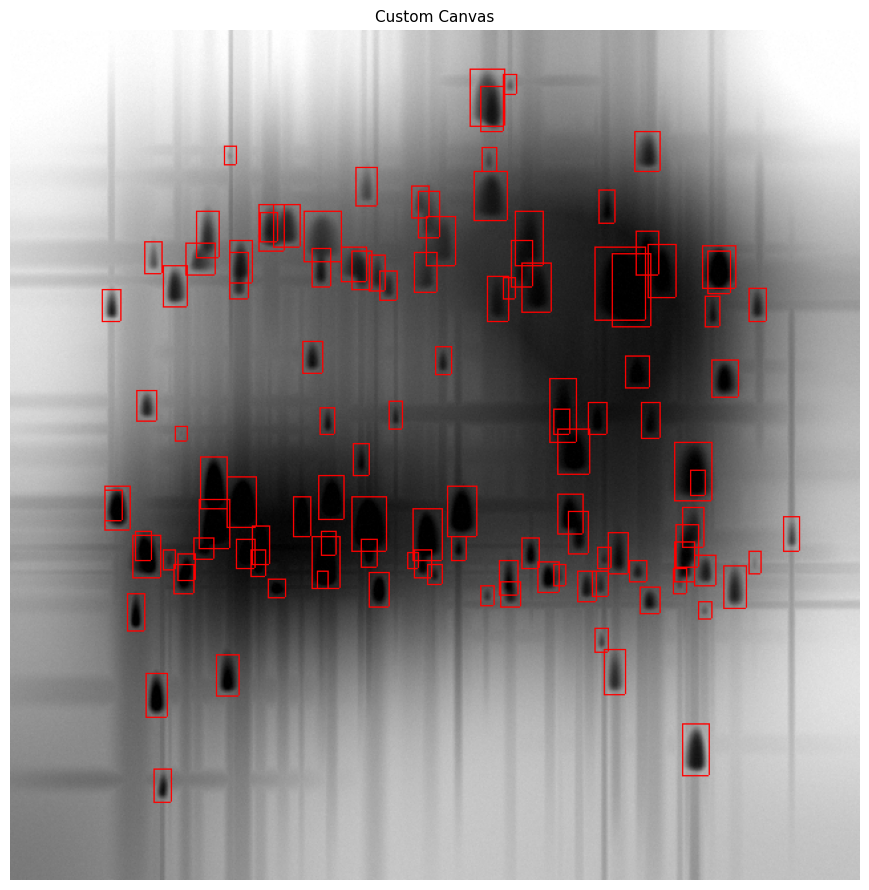

In [ ]:
#@title Visualize Single Sample

spot_type = "complete"        #@param ["complete", "streaked"]
cmap = "gray"                  #@param ["hot", "gray"]
invert = True                 #@param {type:"boolean"}
show_secondary = True         #@param {type:"boolean"}
show_bboxes = True            #@param {type:"boolean"}
show_canvas_distort = True    #@param {type:"boolean"}
show_gaussian_noise = True    #@param {type:"boolean"}
streaks = True #@param {type:"boolean"}
smears = True #@param {type:"boolean"}


show_canvas(sample, spots=spot_type,
            cmap=cmap,
            invert=invert,
            secondary=show_secondary,
            bboxes=show_bboxes,
            canvas_distort=show_canvas_distort,
            gaussian_noise=show_gaussian_noise,
            streaks=streaks,
            smears=smears,
            title=f"Custom Canvas")

## Batch Generate & Save Samples

The actually useful stuff for users.

---

| Default Settings |  |
| --- | :---: |
| spot_type | complete |
| cmap | gray |
| invert | True |
| show_secondary | True |
| show_canvas_distort | True |
| show_gaussian_noise | True |
---
For our first test, set:

- target_path → **/content/drive/MyDrive/2DGEProject/generated_datasets/trial_1/**

- dataset_name → **your name** (or anything really)
  * Be careful of overwriting existing datasets!

- sample_count → **at least 50** per person
  * You can run in several batches within the same dataset location. Just make sure to use different identifiers between runs.

- identifier → **(your_name)_(A, B, C, ...)**
  * Samples will be named (identifier)_(sample no.).
    * For example: finley_A_0, finley_A_1, finley_A_2, ...
  * This is very important for when we merge our datasets. We need to make sure samples from different datasets have different names.
  * Also useful for when you want to resume your generation.
    * For example: I use finley_A, but somehow my generation got interrupted, so I generate the rest with finley_B
    * Samples will always be named from 0 every run, so ensure that they have different identifiers.
  * **Always use a different identifier for different runs**, so they won't overwrite each other when merged!



In [ ]:
#@title Pipeline Batch Run
#@markdown This will produce a folder containing an **images folder** and a **labels folder**.

spot_type            = "complete"  #@param ["complete"]
cmap                 = "gray"      #@param ["hot", "gray"]
invert               = True        #@param {type:"boolean"}
show_secondary       = False        #@param {type:"boolean"}
show_canvas_distort  = True        #@param {type:"boolean"}
show_gaussian_noise  = True        #@param {type:"boolean"}
show_streaks         = True        #@param {type:"boolean"}
show_smears          = True        #@param {type:"boolean"}

sample_config = (spot_type, cmap, invert, show_secondary,
                 show_canvas_distort, show_gaussian_noise,
                 show_streaks, show_smears)

target_path   = "/content/drive/MyDrive/2DGEProject/generated_datasets/trial_2/"        #@param {type:"string"}
dataset_name  = "finley"    #@param {type:"string"}
sample_count  = 100       #@param {type:"integer"}
identifier    = "finley_2F"       #@param {type:"string"}
#@markdown _**IMPORTANT: ALWAYS USE A DIFFERENT IDENTIFIER**_
generate_dataset(
    n=sample_count,
    config=sample_config,
    identifier=identifier,
    target_path=target_path,
    folder_name=dataset_name
)
#@markdown Good luck 👍

Generating 100 samples → /content/drive/MyDrive/2DGEProject/generated_datasets/trial_2/finley
  spot_type      : complete
  cmap           : gray  invert=True
  secondary      : False
  canvas_distort : True
  gaussian_noise : True
  streaks        : True
  smears         : True
  Generating 134 primary spots...
  Done — 134 kept, 0 removed (touched border)
  Generated 134 bounding boxes
  length falloff : spline
  h_perp falloff : cosine
  v_perp falloff : cosine
  h angle        : 0.07°
  v angle        : -0.84°
  Drawing streaks for 134 primary spots...
  Drawing streaks for 0 secondary spots...
  Streak layer — max: 0.2269, non-zero: 368873
  Smear layer — max: 0.8500, non-zero: 409600


/tmp/ipykernel_503/987012593.py:91: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_fn    = plt.cm.get_cmap(cmap)


Saved 134 labels to /content/drive/MyDrive/2DGEProject/generated_datasets/trial_2/finley/labels/finley_2F_0.txt
  [1/100] finley_2F_0 — 134 boxes
  Generating 101 primary spots...
  Done — 101 kept, 0 removed (touched border)
  Generated 101 bounding boxes
  length falloff : spline
  h_perp falloff : cosine
  v_perp falloff : cosine
  h angle        : -0.59°
  v angle        : 1.58°
  Drawing streaks for 101 primary spots...
  Drawing streaks for 0 secondary spots...
  Streak layer — max: 0.2148, non-zero: 324469
  Smear layer — max: 0.8500, non-zero: 407408
Saved 101 labels to /content/drive/MyDrive/2DGEProject/generated_datasets/trial_2/finley/labels/finley_2F_1.txt
  Generating 151 primary spots...
  Done — 151 kept, 0 removed (touched border)
  Generated 151 bounding boxes
  length falloff : spline
  h_perp falloff : cosine
  v_perp falloff : cosine
  h angle        : 0.58°
  v angle        : 0.51°
  Drawing streaks for 151 primary spots...
  Drawing streaks for 0 secondary spots..

# Training Directory Prep DO NOT RUN




In [ ]:
ooga = !ls -p drive/MyDrive/2DGEProject/generated_datasets/trial_2
print(ooga)
ooga = ooga[0].split(sep="/  ")
print(ooga)


['finley/  je/  kiel/  oneal/']
['finley', 'je', 'kiel', 'oneal/']


In [ ]:
ready_to_train = "drive/MyDrive/2DGEProject/generated_datasets/trial_1n2_ready"
!mkdir -p {ready_to_train}/images/train
!mkdir -p {ready_to_train}/labels/train
!mkdir -p {ready_to_train}/images/val
!mkdir -p {ready_to_train}/labels/val

In [ ]:
!ls {ready_to_train}

compiled_images  compiled_labels  images  labels


In [ ]:
train_val_ratio = 0.85


In [ ]:
image_count = 0
# !mkdir {ready_to_train}/compiled_images
for dataset in ooga:
  path = f"drive/MyDrive/2DGEProject/generated_datasets/trial_2/{dataset}/images"
  # !ls -p {path}
  image_list = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
  for image in image_list:
    !cp {path}/{image} {ready_to_train}/compiled_images/{image}
    print(image)
  image_count += len(image_list)
print(image_count)

label_count = 0
# !mkdir {ready_to_train}/compiled_labels
for dataset in ooga:
  path = f"drive/MyDrive/2DGEProject/generated_datasets/trial_2/{dataset}/labels"
  # !ls -p {path}
  label_list = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
  for label in label_list:
    !cp {path}/{label} {ready_to_train}/compiled_labels/{label}
    !print(label)
  label_count += len(label_list)
print(label_count)

finley_2C_19.jpg
finley_2C_2.jpg
finley_2C_7.jpg
finley_2C_34.jpg
finley_2B_4.jpg
finley_2C_4.jpg
finley_2C_41.jpg
finley_2F_4.jpg
finley_2B_5.jpg
finley_2C_49.jpg
finley_2C_44.jpg
finley_2C_21.jpg
finley_2C_35.jpg
finley_2B_0.jpg
finley_2C_36.jpg
finley_2C_20.jpg
finley_2C_13.jpg
finley_2C_37.jpg
finley_2C_29.jpg
finley_2C_15.jpg
finley_2C_0.jpg
finley_2B_6.jpg
finley_2C_8.jpg
finley_2C_30.jpg
finley_2C_28.jpg
finley_2C_6.jpg
finley_2C_24.jpg
finley_2C_42.jpg
finley_2F_5.jpg
finley_2F_6.jpg
finley_2C_46.jpg
finley_2F_0.jpg
finley_2C_12.jpg
finley_2C_38.jpg
finley_2C_32.jpg
finley_2C_11.jpg
finley_2C_10.jpg
finley_2C_16.jpg
finley_2F_3.jpg
finley_2C_40.jpg
finley_2F_1.jpg
finley_2C_9.jpg
finley_2C_31.jpg
finley_2B_3.jpg
finley_2C_39.jpg
finley_2C_43.jpg
finley_2C_45.jpg
finley_2C_27.jpg
finley_2F_2.jpg
finley_2C_17.jpg
finley_2C_33.jpg
finley_2C_5.jpg
finley_2C_25.jpg
finley_2C_22.jpg
finley_2C_47.jpg
finley_2C_48.jpg
finley_2C_23.jpg
finley_2B_2.jpg
finley_2C_14.jpg
finley_2B_1.jpg
fi

In [ ]:
train_count = math.ceil(((image_count+370) * 0.85))
val_count = 76 #image_count - train_count +370
print(train_count, val_count)

717 76


In [ ]:
#assign images to which group
compiled_images_folder = f"{ready_to_train}/compiled_images/"
compiled_images = [f for f in os.listdir(compiled_images_folder) if os.path.isfile(os.path.join(compiled_images_folder, f))]
random.shuffle(compiled_images)
print(compiled_images)
images_to_train = compiled_images[0:train_count]
images_to_val = compiled_images[train_count:]
print(len(images_to_train))
print(len(images_to_val))


#assign labels to which group. just copy from images but rename .jpg to .txt
compiled_labels_folder = f"{ready_to_train}/compiled_labels/"
compiled_labels = [item.replace(".jpg", ".txt") for item in compiled_images]
print(compiled_labels)
labels_to_train = compiled_labels[0:train_count]
labels_to_val = compiled_labels[train_count:]
print(len(labels_to_train))
print(len(labels_to_val))


['oneal_E_29.jpg', 'jess_2B_49.jpg', 'finley_B_19.jpg', 'oneal_E_1.jpg', 'jess_2B_43.jpg', 'kiel_A_30.jpg', 'jess_A_48.jpg', 'kiel_B_7.jpg', 'finley_2D_21.jpg', 'jess_A_43.jpg', 'jess_2B_44.jpg', 'jess_2B_6.jpg', 'oneal_D_8.jpg', 'jess_C_19.jpg', 'jess_A_9.jpg', 'finley_B_8.jpg', 'jess_C_2.jpg', 'jess_C_13.jpg', 'oneal_A_35.jpg', 'oneal_2A_25.jpg', 'kiel_B_28.jpg', 'oneal_B_7.jpg', 'jess_2B_16.jpg', 'kiel_B_19.jpg', 'kiel_B_34.jpg', 'finley_D_0.jpg', 'kiel_B_33.jpg', 'finley_C_16.jpg', 'jess_A_40.jpg', 'oneal_A_17.jpg', 'kiel_B_13.jpg', 'oneal_2B_18.jpg', 'jess_A_49.jpg', 'finley_2D_18.jpg', 'jess_C_21.jpg', 'jess_B_11.jpg', 'jess_B_0.jpg', 'finley_2C_37.jpg', 'kiel_A_36.jpg', 'oneal_D_14.jpg', 'oneal_A_36.jpg', 'oneal_E_13.jpg', 'jess_B_10.jpg', 'jess_C_24.jpg', 'finley_2D_33.jpg', 'oneal_B_13.jpg', 'jess_2A_29.jpg', 'finley_C_19.jpg', 'jess_2B_41.jpg', 'jess_2A_47.jpg', 'oneal_D_6.jpg', 'jess_2A_6.jpg', 'finley_2C_40.jpg', 'oneal_D_13.jpg', 'jess_C_1.jpg', 'finley_B_13.jpg', 'oneal_2

In [ ]:
for image in images_to_train:
  !mv {ready_to_train}/compiled_images/{image} {ready_to_train}/images/train/{image}
for image in images_to_val:
  !mv {ready_to_train}/compiled_images/{image} {ready_to_train}/images/val/{image}

for label in labels_to_train:
  !mv {ready_to_train}/compiled_labels/{label} {ready_to_train}/labels/train/{label}
for label in labels_to_val:
  !mv {ready_to_train}/compiled_labels/{label} {ready_to_train}/labels/val/{label}

In [ ]:
!echo "hello" > {ready_to_train}/data.yaml